First we set current project root.

In [ ]:
import sys
from pathlib import Path

# Try to locate the project root by looking for a directory that contains 'src'
cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent, cwd.parent.parent]

PROJECT_ROOT = None
for path in candidate_roots:
    if (path / "src").exists():
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not find project root containing 'src'.")

# Add project root to Python path so 'from src...' imports work
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root set to: {PROJECT_ROOT}")


Project root set to: C:\Users\User\git\personal_projects\market-regimes-trading-signals\market-regimes-trading-signals


Now we import our constants.

In [2]:
from src.config import (
    PROJECT_ROOT,
    DATA_RAW_DIR,
    DATA_PROCESSED_DIR,
    TICKERS,
    START_DATE,
    END_DATE,
)
from src.data import DataConfig, build_and_save_market_dataset

Assign these constants into a local DataConfig. Build our dataset and print the 5 entries beginning from the earliest data, 2012-01-03.

In [3]:
config = DataConfig(
    tickers=TICKERS,
    start_date=START_DATE,
    end_date=END_DATE,
    raw_dir=DATA_RAW_DIR,
    processed_dir=DATA_PROCESSED_DIR,
)

df = build_and_save_market_dataset(config)
df.head()

,spy_close,spy_adj_close,spy_volume,vix_close,vix_adj_close,tnx_close,tnx_adj_close
date,,,,,,,
2012-01-03,127.500000,99.312202,193697900,22.969999,22.969999,1.960,1.960
2012-01-04,127.699997,99.467979,127186500,22.219999,22.219999,1.995,1.995
2012-01-05,128.039993,99.732811,173895000,21.480000,21.480000,1.993,1.993
2012-01-06,127.709999,99.475807,148050000,20.629999,20.629999,1.961,1.961
2012-01-09,128.020004,99.717224,99530200,21.070000,21.070000,1.960,1.960


Print the most recent 5 entries.

In [4]:
df.tail()

,spy_close,spy_adj_close,spy_volume,vix_close,vix_adj_close,tnx_close,tnx_adj_close
date,,,,,,,
2026-03-20,648.570007,648.570007,163617500,26.780001,26.780001,4.391,4.391
2026-03-23,655.380005,655.380005,134802700,26.150000,26.150000,4.334,4.334
2026-03-24,653.179993,653.179993,96457500,26.950001,26.950001,4.392,4.392
2026-03-25,656.820007,656.820007,90506500,25.330000,25.330000,4.328,4.328
2026-03-26,650.520081,650.520081,41639719,26.980000,26.980000,4.388,4.388


Plot our values over the total time period.

array([<Axes: title={'center': 'SPY Adjusted Close'}, xlabel='date'>,
       <Axes: title={'center': 'VIX Close'}, xlabel='date'>,
       <Axes: title={'center': '10Y Treasury Yield Proxy'}, xlabel='date'>],
      dtype=object)

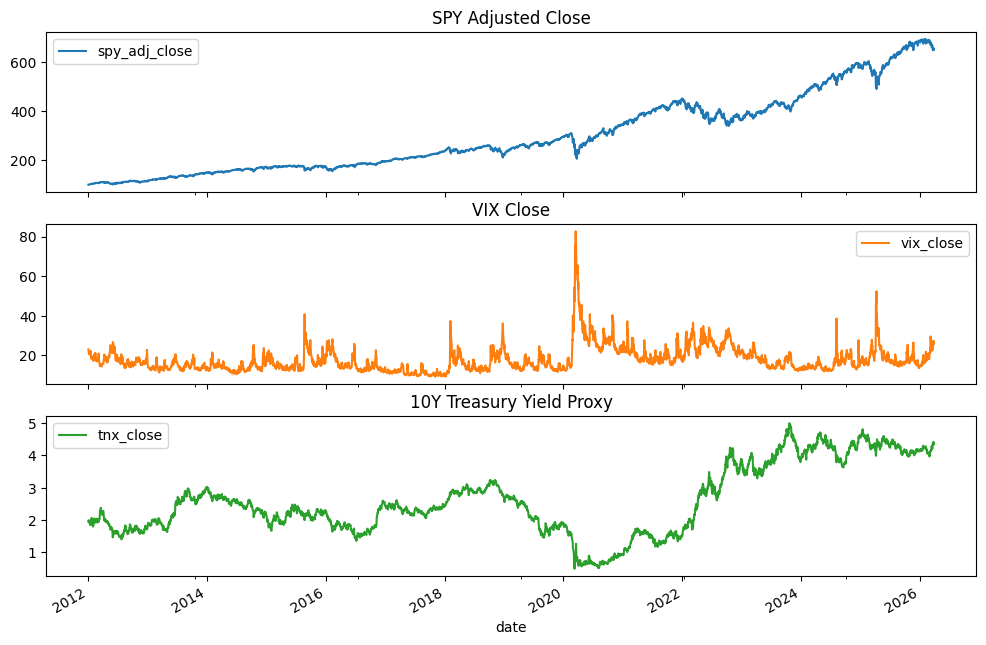

In [5]:
df[["spy_adj_close", "vix_close", "tnx_close"]].plot(
    subplots=True,
    figsize=(12, 8),
    title=["SPY Adjusted Close", "VIX Close", "10Y Treasury Yield Proxy"],
)